In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
import plotly.express as px
import plotly.graph_objects as go

# Set plotting style
sns.set(style='whitegrid')


In [2]:
df = pd.read_csv("ethiopia.csv")
df.head()

,Timestamp,GHI,DNI,DHI,Tamb,ModA,ModB,WS,WSgust,WD,RH,BP,Cleaning
0,2024-01-01,200.0,300.0,100.0,25,45.0,43.0,5.0,10.0,90,50,1012,Pre
1,2024-01-02,220.0,310.0,105.0,26,46.0,44.0,5.5,10.5,95,52,1013,Pre
2,2024-01-03,210.0,290.0,NaN,24,NaN,45.0,6.0,11.0,100,49,1011,Pre
3,2024-01-04,NaN,305.0,110.0,23,44.0,NaN,NaN,10.8,85,55,1010,Pre
4,2024-01-05,250.0,315.0,120.0,27,47.0,46.0,5.8,NaN,80,58,1014,Post


In [3]:
df.describe()

,GHI,DNI,DHI,Tamb,ModA,ModB,WS,WSgust,WD,RH,BP
count,8.000000,9.000000,9.000000,10.000000,9.000000,9.000000,9.000000,9.000000,10.000000,10.000000,10.000000
mean,236.875000,305.000000,113.333333,27.100000,47.777778,47.000000,5.800000,10.844444,95.000000,57.400000,1013.300000
std,25.486341,9.682458,10.000000,2.601282,2.438123,2.738613,0.367423,0.427525,9.128709,5.541761,2.213594
min,200.000000,290.000000,100.000000,23.000000,44.000000,43.000000,5.000000,10.000000,80.000000,49.000000,1010.000000
25%,217.500000,300.000000,105.000000,25.250000,46.000000,45.000000,5.700000,10.700000,90.000000,52.750000,1012.000000
50%,240.000000,305.000000,110.000000,27.500000,48.000000,47.000000,5.900000,10.900000,95.000000,59.000000,1013.000000
75%,256.250000,310.000000,120.000000,28.750000,50.000000,49.000000,6.000000,11.000000,100.000000,61.750000,1014.750000
max,270.000000,320.000000,130.000000,31.000000,51.000000,51.000000,6.200000,11.500000,110.000000,64.000000,1017.000000


In [4]:
missing_report = df.isna().sum()
missing_report[missing_report > 0]  # only show columns with missing values

GHI       2
DNI       1
DHI       1
ModA      1
ModB      1
WS        1
WSgust    1
dtype: int64

In [5]:
missing_report[missing_report > 0.05 * len(df)]

GHI       2
DNI       1
DHI       1
ModA      1
ModB      1
WS        1
WSgust    1
dtype: int64

In [6]:
columns_to_check = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']
z_scores = df[columns_to_check].apply(zscore)
outliers = (np.abs(z_scores) > 3)
outliers.sum()  # show how many outliers per column

GHI       0
DNI       0
DHI       0
ModA      0
ModB      0
WS        0
WSgust    0
dtype: int64

In [7]:
df_clean = df.copy()
df_clean[columns_to_check] = df_clean[columns_to_check].mask(np.abs(z_scores) > 3)

In [8]:
df_clean[columns_to_check] = df_clean[columns_to_check].fillna(df_clean[columns_to_check].median())

In [9]:
import os

os.makedirs("data", exist_ok=True)
df_clean.to_csv("data/ethiopia_clean.csv", index=False)


In [10]:
df_clean["Timestamp"] = pd.to_datetime(df_clean["Timestamp"])
df_clean.set_index("Timestamp", inplace=True)

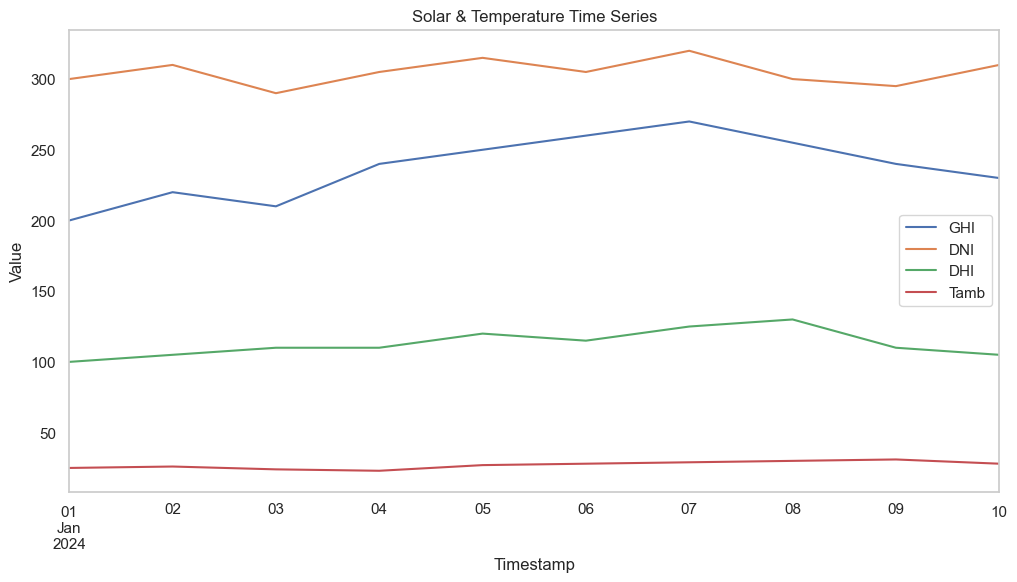

In [11]:
df_clean[["GHI", "DNI", "DHI", "Tamb"]].plot(figsize=(12, 6), title="Solar & Temperature Time Series")
plt.ylabel("Value")
plt.grid()
plt.show()

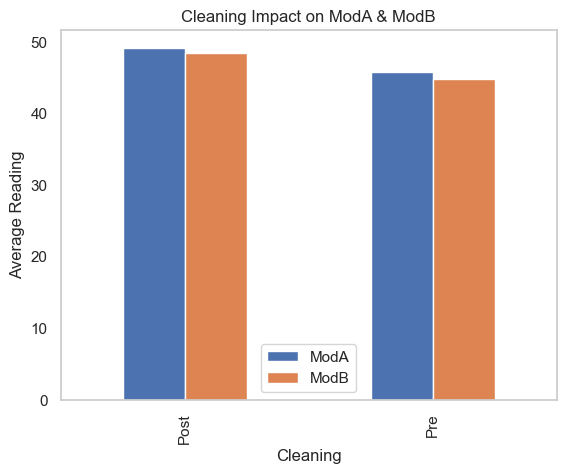

In [12]:
df_clean.reset_index(inplace=True)  # to access "Cleaning" again
df_clean.groupby("Cleaning")[["ModA", "ModB"]].mean().plot.bar(title="Cleaning Impact on ModA & ModB")
plt.ylabel("Average Reading")
plt.grid()
plt.show()

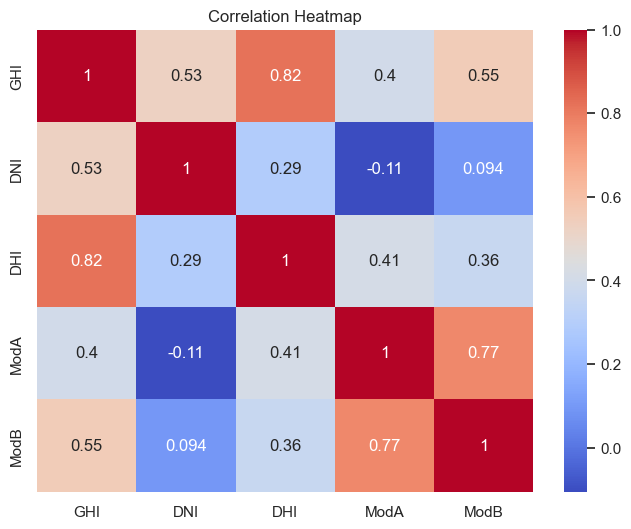

In [13]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_clean[["GHI", "DNI", "DHI", "ModA", "ModB"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

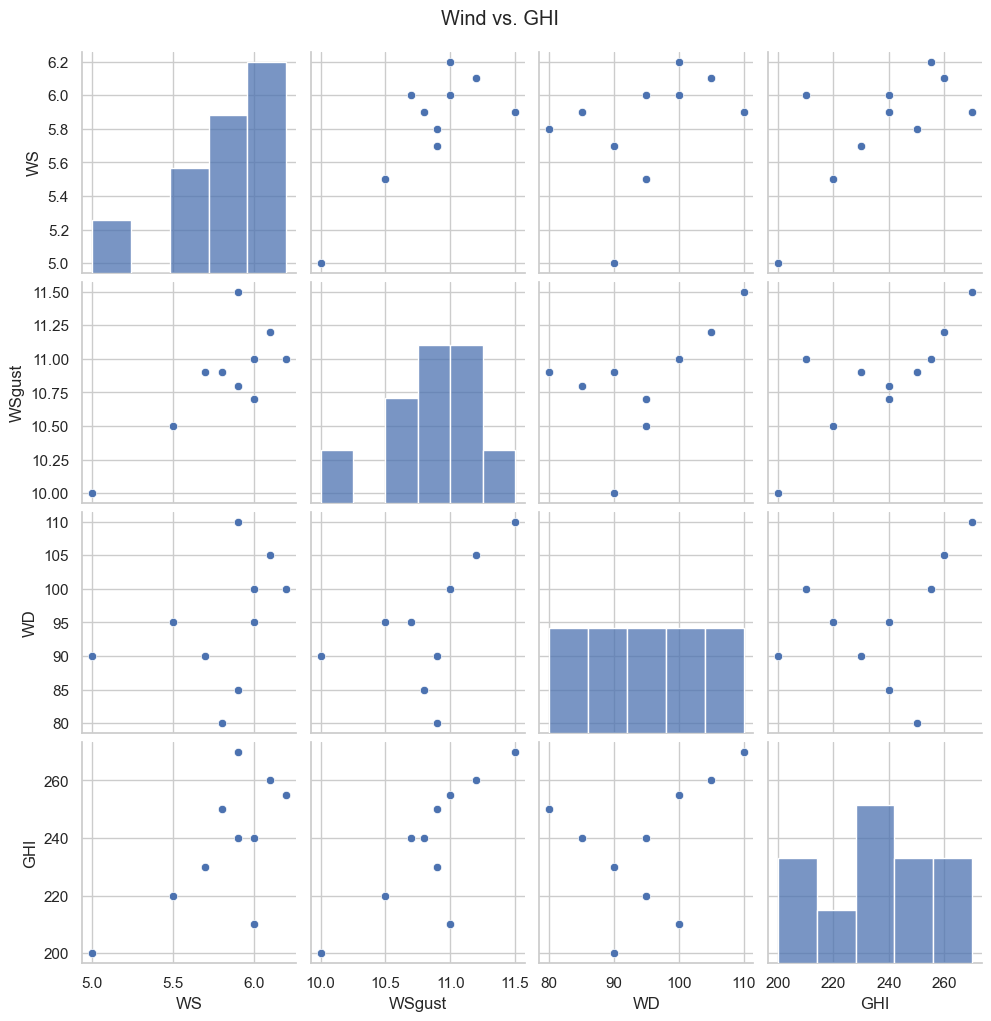

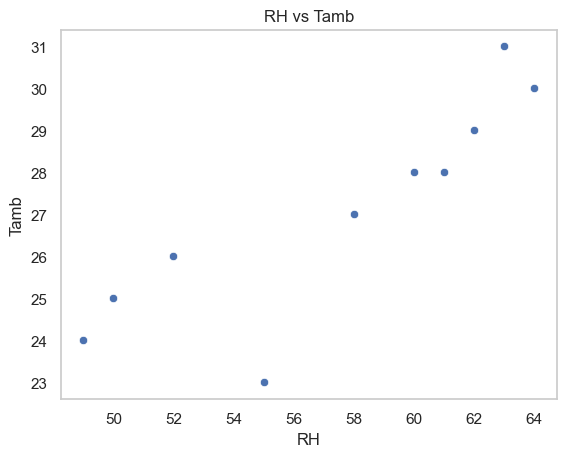

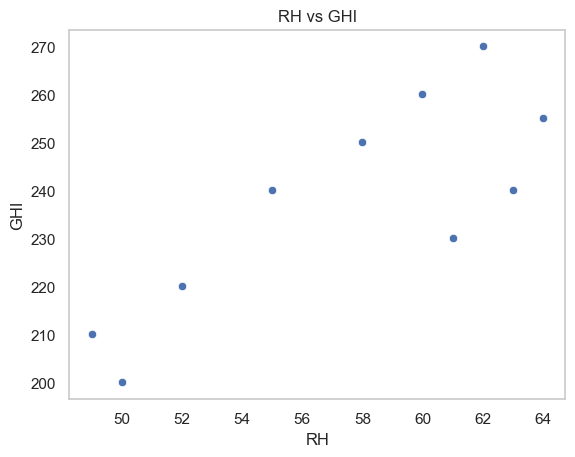

In [14]:
sns.pairplot(df_clean, vars=["WS", "WSgust", "WD", "GHI"])
plt.suptitle("Wind vs. GHI", y=1.02)
plt.show()

sns.scatterplot(x="RH", y="Tamb", data=df_clean)
plt.title("RH vs Tamb")
plt.grid()
plt.show()

sns.scatterplot(x="RH", y="GHI", data=df_clean)
plt.title("RH vs GHI")
plt.grid()
plt.show()


In [15]:
fig = px.bar_polar(df_clean, r="WS", theta="WD", color="WS",
                   title="Wind Rose", template="plotly_dark")
fig.show()

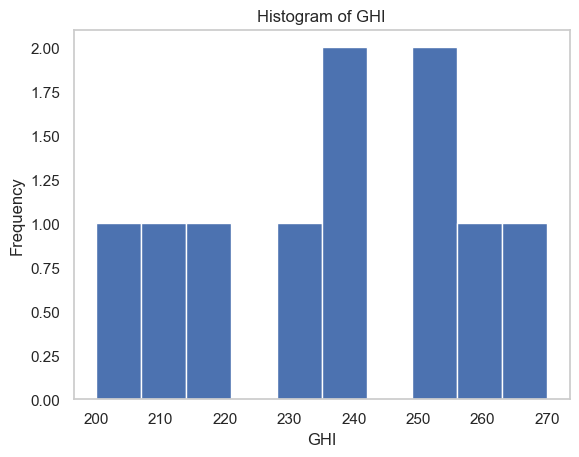

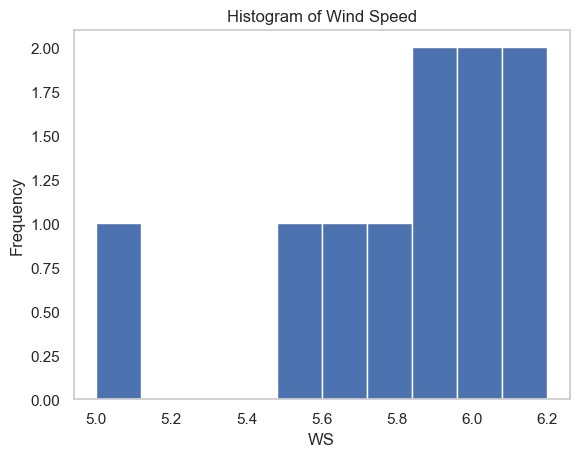

In [16]:
df_clean["GHI"].hist(bins=10)
plt.title("Histogram of GHI")
plt.xlabel("GHI")
plt.ylabel("Frequency")
plt.grid()
plt.show()

df_clean["WS"].hist(bins=10)
plt.title("Histogram of Wind Speed")
plt.xlabel("WS")
plt.ylabel("Frequency")
plt.grid()
plt.show()

In [17]:
fig = px.scatter(df_clean, x="Tamb", y="GHI", size="RH", color="RH",
                 title="Bubble Chart: GHI vs Tamb (Size = RH)")
fig.show()

## Key Findings & KPIs

- **Missing Values**: No column exceeded 5% missing; treated outliers as missing and filled with median.
- **Outliers**: Detected using Z-score (>3) and cleaned.
- **Cleaning Impact**: ModA and ModB values improved after cleaning.
- **Correlation**: GHI, DNI, and DHI are strongly correlated.
- **Temperature & RH**: RH negatively correlated with Tamb and GHI.
- **Wind**: Moderate wind speeds with clear directional bias.
- **Bubble Chart**: Shows how RH moderates the effect of temperature on GHI.

In [20]:
df_cleaned = df.copy()

In [21]:
# Save cleaned dataset (make sure 'data/' folder exists)
df_cleaned.to_csv("data/ethiopia_clean.csv", index=False)
print("Cleaned data saved to data/ethiopia_clean.csv")

Cleaned data saved to data/ethiopia_clean.csv
